# Business Understanding

ini akan memprediksi apakah karyawana kan di promosikan atau tidak

# Data Understanding

understanding teh data

# Import data dan package

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('Salinan dari Human Capital - Human Capital.csv')
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted,new_education,Range_Age
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0,Master's & above,2. 31-40 tahun
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0,Bachelor's,1. 20-30 tahun
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0,Bachelor's,2. 31-40 tahun
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0,Bachelor's,2. 31-40 tahun
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0,Bachelor's,3. 41-50 tahun


In [ ]:
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted,new_education,Range_Age
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78.0,0,Bachelor's,3. 41-50 tahun
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56.0,0,Master's & above,2. 31-40 tahun
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79.0,0,Bachelor's,1. 20-30 tahun
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,NaN,0,Others,1. 20-30 tahun
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,49.0,0,Bachelor's,1. 20-30 tahun


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
 13  new_education         54808 non-null  object 
 14  Range_Age             54808 non-null  object 
dtypes: float64(2), int6

1. kolom yang akan di drop adalah employee_id, education, dan Range_Age
2. is_promoted ini akan menjadi label untuk prediksi

In [ ]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,52248.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.712238,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.521910,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,77.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


# Pre-processing data

In [ ]:
print(df.isnull().sum())

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won                 0
avg_training_score      2560
is_promoted                0
new_education              0
Range_Age                  0
dtype: int64


1. kolom education akan di drop karena sudah ada kolom new education,
2. missing value pada previous_year_rating akan diisi dengan nilai 0 sebagai anggapan bahwa previous_year_rating yang tidak terisi adalah karyawan baru yang belum setahun,
3. missing value pada avg_training_score akan diisi dengan nilai mean agar tidak bias

In [ ]:
print(df.duplicated().sum())

0


1. memastikan tidak ada data duplikat dan memastikan bahwa employee_id adalah primary key yang selanjutnya akan di drop

In [ ]:
df = df.drop(columns=['education','employee_id','Range_Age'])
df.head()

,department,region,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted,new_education
0,Sales & Marketing,region_7,f,sourcing,1,35,5.0,8,0,49.0,0,Master's & above
1,Operations,region_22,m,other,1,30,5.0,4,0,60.0,0,Bachelor's
2,Sales & Marketing,region_19,m,sourcing,1,34,3.0,7,0,50.0,0,Bachelor's
3,Sales & Marketing,region_23,m,other,2,39,1.0,10,0,50.0,0,Bachelor's
4,Technology,region_26,m,other,1,45,3.0,2,0,73.0,0,Bachelor's


In [ ]:
# Isi avg_training_score dengan rata-rata dan previous_year_rating dengan 0
df['avg_training_score'] = df['avg_training_score'].fillna(df['avg_training_score'].mean())
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)

In [ ]:
df.head()

,department,region,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted,new_education
0,Sales & Marketing,region_7,f,sourcing,1,35,5.0,8,0,49.0,0,Master's & above
1,Operations,region_22,m,other,1,30,5.0,4,0,60.0,0,Bachelor's
2,Sales & Marketing,region_19,m,sourcing,1,34,3.0,7,0,50.0,0,Bachelor's
3,Sales & Marketing,region_23,m,other,2,39,1.0,10,0,50.0,0,Bachelor's
4,Technology,region_26,m,other,1,45,3.0,2,0,73.0,0,Bachelor's


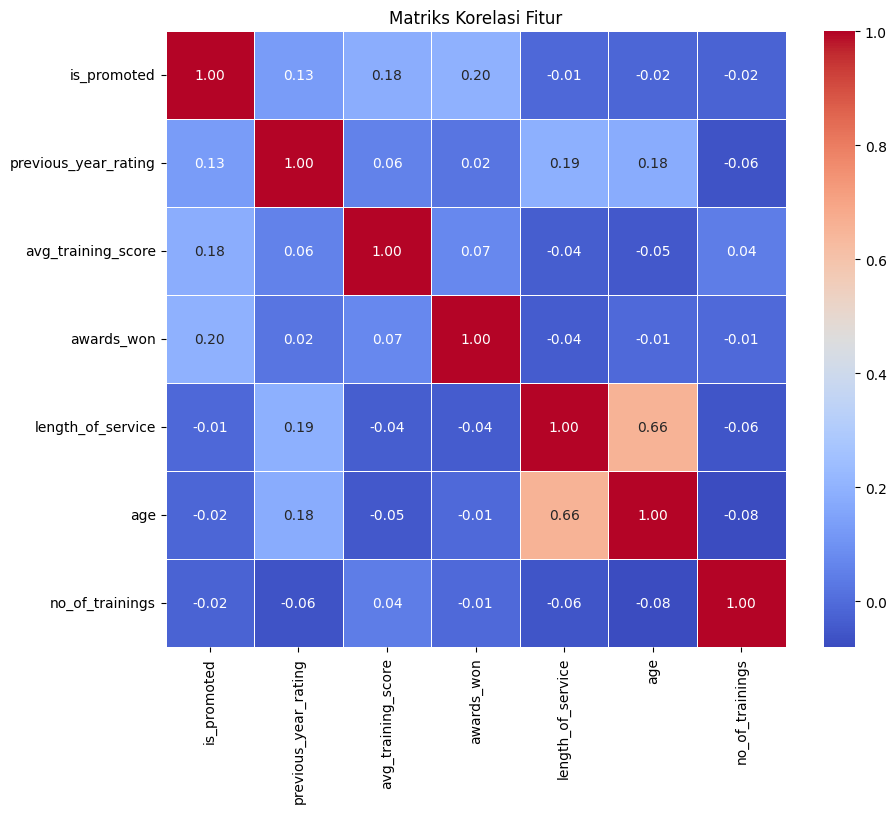

In [ ]:
cols = ['is_promoted', 'previous_year_rating', 'avg_training_score',
        'awards_won', 'length_of_service', 'age',
        'no_of_trainings']

# Hitung Matriks Korelasi
corr_matrix = df[cols].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur')
plt.show()

In [ ]:
df.to_csv('hr_data_processed.csv', index=False)

# Data Analysis

pertanyaan yang akan di jawab :
1. overview
2. Divisi mana yang paling banyak melakukan promosi?
3. Apakah kinerja berdampak langsung pada promosi?
4. Apakah training meningkatkan kemungkinan promosi?
5. Apakah promosi berhubungan dengan umur?

In [ ]:
# 1 overview data
print("=== OVERVIEW METRICS ===")
print(f"Total Karyawan       : {len(df)}")
print(f"Promotion Rate Total : {df['is_promoted'].mean() * 100:.2f}%")
print(f"Rata-rata Skor Training: {df['avg_training_score'].mean():.2f}")
print("========================")

=== OVERVIEW METRICS ===
Total Karyawan       : 54808
Promotion Rate Total : 8.52%
Rata-rata Skor Training: 63.71


/tmp/ipython-input-946260627.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_promo.values, y=dept_promo.index, palette='viridis')


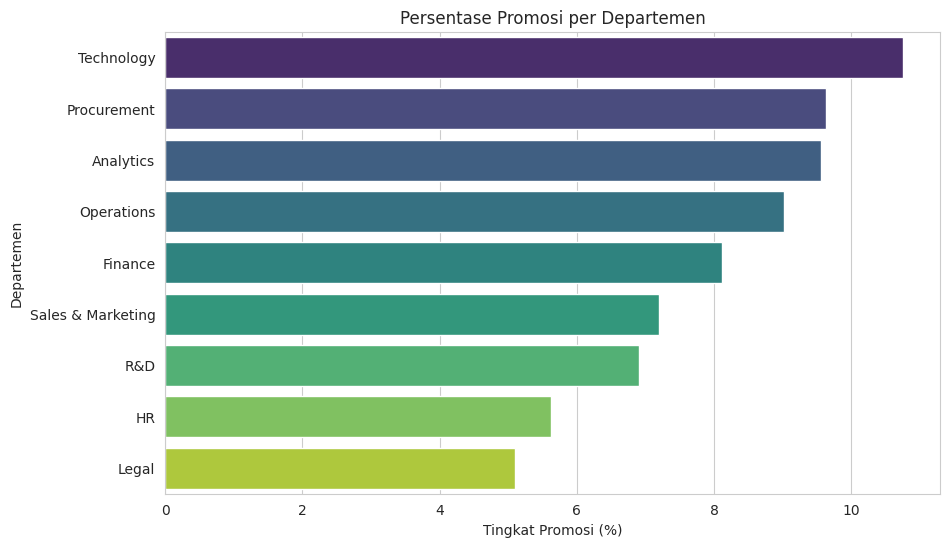

In [ ]:
# Setting Visual Style
sns.set_style("whitegrid")

# --- VISUALISASI 1: Promosi per Departemen ---
plt.figure(figsize=(10, 6))
# Menghitung % promosi per dept
dept_promo = df.groupby('department')['is_promoted'].mean().sort_values(ascending=False) * 100
sns.barplot(x=dept_promo.values, y=dept_promo.index, palette='viridis')
plt.title('Persentase Promosi per Departemen')
plt.xlabel('Tingkat Promosi (%)')
plt.ylabel('Departemen')
plt.show()

/tmp/ipython-input-3324618795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_promo.index, y=rating_promo.values, palette='Blues_d')


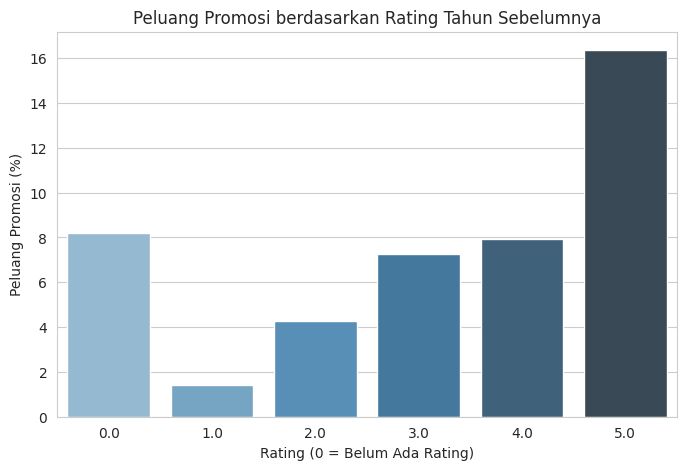

In [ ]:
# --- VISUALISASI 2: Dampak Kinerja (Rating) ---
plt.figure(figsize=(8, 5))
rating_promo = df.groupby('previous_year_rating')['is_promoted'].mean() * 100
sns.barplot(x=rating_promo.index, y=rating_promo.values, palette='Blues_d')
plt.title('Peluang Promosi berdasarkan Rating Tahun Sebelumnya')
plt.ylabel('Peluang Promosi (%)')
plt.xlabel('Rating (0 = Belum Ada Rating)')
plt.show()

/tmp/ipython-input-734017684.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=awards_promo.index, y=awards_promo.values, palette='pastel')


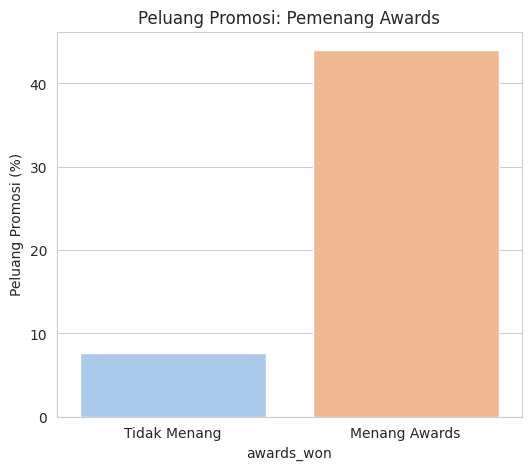

In [ ]:
# --- VISUALISASI 3: Dampak Awards ---
plt.figure(figsize=(6, 5))
awards_promo = df.groupby('awards_won')['is_promoted'].mean() * 100
sns.barplot(x=awards_promo.index, y=awards_promo.values, palette='pastel')
plt.title('Peluang Promosi: Pemenang Awards')
plt.ylabel('Peluang Promosi (%)')
plt.xticks([0, 1], ['Tidak Menang', 'Menang Awards'])
plt.show()

/tmp/ipython-input-3717579367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_promoted', y='avg_training_score', data=df, palette='Set2')


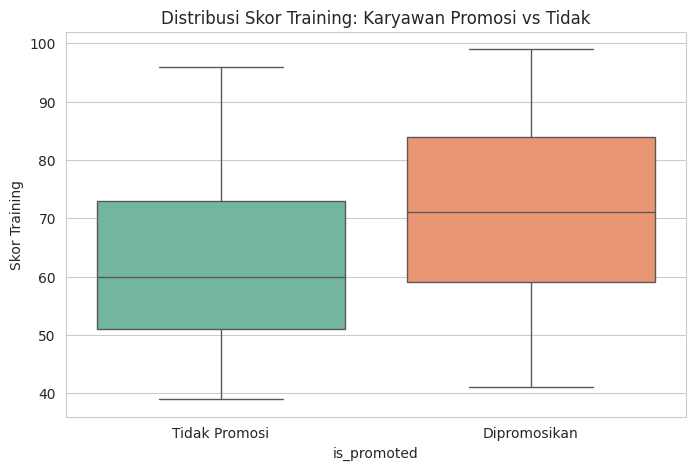

In [ ]:
# --- VISUALISASI 4: Dampak Skor Training ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_promoted', y='avg_training_score', data=df, palette='Set2')
plt.title('Distribusi Skor Training: Karyawan Promosi vs Tidak')
plt.ylabel('Skor Training')
plt.xticks([0, 1], ['Tidak Promosi', 'Dipromosikan'])
plt.show()

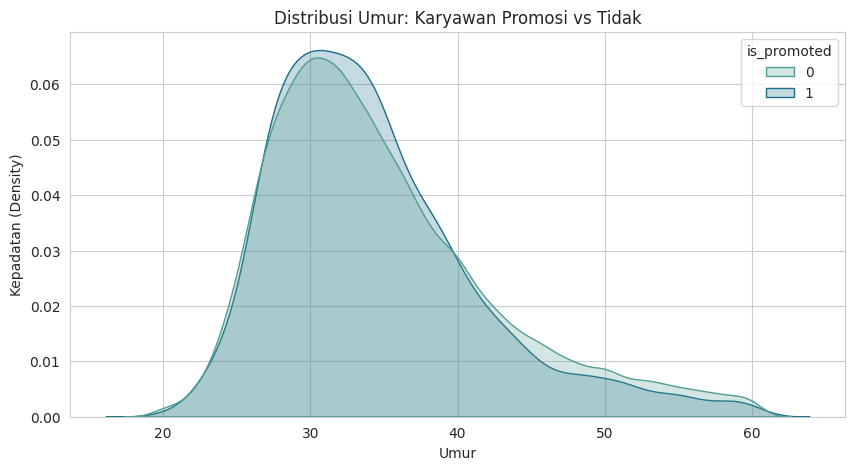

In [ ]:
# --- VISUALISASI 5: Hubungan dengan Umur ---
plt.figure(figsize=(10, 5))
# KDE Plot untuk melihat kepadatan distribusi umur
sns.kdeplot(data=df, x='age', hue='is_promoted', fill=True, common_norm=False, palette='crest')
plt.title('Distribusi Umur: Karyawan Promosi vs Tidak')
plt.xlabel('Umur')
plt.ylabel('Kepadatan (Density)')
plt.show()

# Encoding

In [ ]:
# Label Encoding untuk Gender dan Education
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['new_education'] = le.fit_transform(df['new_education'])

In [ ]:
df = pd.get_dummies(df, columns=['department', 'recruitment_channel', 'region'], drop_first=True, dtype=int)

In [ ]:
# Cek hasil data siap pakai
print("Dimensi data setelah pre-processing:", df.shape)
print(df.head())

Dimensi data setelah pre-processing: (54808, 52)
   gender  no_of_trainings  age  previous_year_rating  length_of_service  \
0       0                1   35                   5.0                  8   
1       1                1   30                   5.0                  4   
2       1                1   34                   3.0                  7   
3       1                2   39                   1.0                 10   
4       1                1   45                   3.0                  2   

   awards_won  avg_training_score  is_promoted  new_education  \
0           0                49.0            0              2   
1           0                60.0            0              0   
2           0                50.0            0              0   
3           0                50.0            0              0   
4           0                73.0            0              0   

   department_Finance  ...  region_region_31  region_region_32  \
0                   0  ...           

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 52 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        54808 non-null  int64  
 1   no_of_trainings               54808 non-null  int64  
 2   age                           54808 non-null  int64  
 3   previous_year_rating          54808 non-null  float64
 4   length_of_service             54808 non-null  int64  
 5   awards_won                    54808 non-null  int64  
 6   avg_training_score            54808 non-null  float64
 7   is_promoted                   54808 non-null  int64  
 8   new_education                 54808 non-null  int64  
 9   department_Finance            54808 non-null  int64  
 10  department_HR                 54808 non-null  int64  
 11  department_Legal              54808 non-null  int64  
 12  department_Operations         54808 non-null  int64  
 13  d

# Modelling

In [ ]:
# Pisahkan Fitur (X) dan Target (y)
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

In [ ]:
# stratify=y memastikan proporsi promosi di train dan test sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
num_cols = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score']

In [ ]:
# Fit pada training, transform pada training & test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
# 3. Training Model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

# Evaluation

In [ ]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[9974   54]
 [ 686  248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10028
           1       0.82      0.27      0.40       934

    accuracy                           0.93     10962
   macro avg       0.88      0.63      0.68     10962
weighted avg       0.93      0.93      0.92     10962



# Tuning Hyperparameter

In [ ]:
param_dist = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(random_state=42)

In [ ]:
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                               n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='f1')

In [ ]:
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 150, 200, 300]},
                   random_state=42, scoring='f1', verbose=2)

In [ ]:
best_model = rf_random.best_estimator_

In [ ]:
print("\nParameter Terbaik Ditemukan:")
print(rf_random.best_params_)


Parameter Terbaik Ditemukan:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced', 'bootstrap': True}


In [ ]:
y_pred = best_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[9736  292]
 [ 576  358]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     10028
           1       0.55      0.38      0.45       934

    accuracy                           0.92     10962
   macro avg       0.75      0.68      0.70     10962
weighted avg       0.91      0.92      0.91     10962



# Save Model

In [ ]:
import pickle

with open('hr_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("\nModel hasil tuning berhasil disimpan sebagai 'hr_model.pkl'.")


Model hasil tuning berhasil disimpan sebagai 'hr_model.pkl'.


#